# 11장 실습 — 조작은 왜 어려운가

10장은 로코모션의 처방을 이 책의 밀기 과제에 옮겨 봤다. 특권 교사를 세우고, 관측 가능한 이력만 보는 학생에게 증류했다. 그리고 한 가지를 확인했다 — **숨은 마찰은 이력에 지문을 남긴다.** 선형회귀만으로도 분산의 3분의 1 이상이 설명됐다.

그 실험에는 전제가 하나 숨어 있었다. **블록이 어디 있는지는 처음부터 알려 줬다.** 관측 여덟 개 중 여섯 개가 블록에 관한 것이었다.

실기에서는 그 여섯 개가 공짜가 아니다. 다리 로봇은 관절 엔코더와 IMU만으로 자기 상태를 다 읽지만, 물체를 미는 로봇은 **물체의 상태를 자기 몸에서 읽을 수 없다.** 이 노트북은 그 차이가 얼마짜리인지 잰다.

실행 시간은 CPU에서 6분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


## 관측을 세 가지로 자른다

물리는 고정한다. 마찰도 게인도 지연도 흔들지 않는다. **이번에 바꾸는 것은 정책이 무엇을 볼 수 있는가 하나뿐**이다.

- **전체 상태** — 여덟 개. 10장까지 써 온 그대로다. 블록의 위치와 속도가 들어 있다
- **고유수용만** — 네 개. 목표까지의 상대 위치와 밀대의 속도뿐이다. 로봇이 자기 몸에서 읽을 수 있는 것만 남긴 것이다
- **고유수용 + 이력** — 네 개에 최근 여섯 스텝의 (고유수용, 행동)을 붙여 마흔 개. **10장에서 마찰을 복원해 준 바로 그 처방**이다

세 번째가 이 노트북의 주인공이다. 로코모션에서 통한 처방이 조작에서도 통하는가.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
K = 6
DIN = {"full": 8, "proprio": 4, "hist": 4 + 6 * K}


class Vec:
    # noise 와 drop 은 「블록을 카메라로 본다」를 흉내 내는 손잡이다
    def __init__(self, n, seed=0, noise=0., drop=0.):
        self.m = mujoco.MjModel.from_xml_string(XML)
        self.sub = int(round(1 / 20 / self.m.opt.timestep))
        self.n, self.noise, self.drop = n, noise, drop
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.seen = np.zeros((n, 2))       # 마지막으로 본 블록 위치
        self.hist = [None] * n
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
        self.seen[i] = d.qpos[0:2]
        self.hist[i] = [np.zeros(6, np.float32) for _ in range(K)]

    def block_seen(self, i):
        # 카메라가 보는 블록. 잡음이 섞이고 가끔 갱신을 놓친다
        d = self.d[i]
        if self.drop and self.rng.random() < self.drop:
            return self.seen[i]
        b = np.asarray(d.qpos[0:2], float)
        if self.noise:
            b = b + self.rng.normal(0, self.noise, 2)
        self.seen[i] = b
        return b

    def proprio(self, i):
        d = self.d[i]
        o = np.empty(4, np.float32)
        o[0:2] = self.g[i] - d.qpos[7:9]
        o[2:4] = d.qvel[6:8]
        return o * np.float32(10.)

    def full(self, i):
        d = self.d[i]
        b = self.block_seen(i)
        o = np.empty(8, np.float32)
        o[0:2] = self.g[i] - b
        o[2:4] = d.qvel[0:2]
        o[4:6] = b - d.qpos[7:9]
        o[6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def obs(self, kind):
        if kind == "full":
            return np.stack([self.full(i) for i in range(self.n)])
        if kind == "proprio":
            return np.stack([self.proprio(i)
                             for i in range(self.n)])
        return np.stack([
            np.concatenate([self.proprio(i)] + self.hist[i]
                           ).astype(np.float32)
            for i in range(self.n)])

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        done = np.zeros(self.n, np.float32)
        succ = []
        for i, d in enumerate(self.d):
            cl = np.clip(a[i], -1, 1)
            self.hist[i].append(
                np.concatenate([self.proprio(i), cl]
                               ).astype(np.float32))
            self.hist[i] = self.hist[i][-K:]
            d.ctrl[:] = cl * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                done[i] = 1.
                succ.append(float(db < GOAL_R))
                self.reset(i)
        return r, done, succ

## 학습기

8장부터 써 온 PPO 그대로다. 관측 차원만 바뀐다.

In [4]:
class AC(nn.Module):
    def __init__(self, din):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train(kind, budget, seed=0, lr=3e-3, n=16, T=32):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    din = DIN[kind]
    ac = AC(din)
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs(kind)
    steps = 0
    while steps < budget:
        O = np.empty((T, n, din), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                dist = ac.dist(ot)
                a = dist.sample()
                LP[t] = dist.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs(kind)
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, din))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                dist = ac.dist(bo[j])
                lp = dist.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * dist.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


def score(ac, kind, n=300, noise=0., drop=0., seed=999):
    torch.manual_seed(seed)          # 평가끼리 견줄 수 있게 고정
    env = Vec(8, seed, noise=noise, drop=drop)
    got = []
    while len(got) < n:
        o = torch.from_numpy(env.obs(kind))
        with torch.no_grad():
            u = ac.dist(o).sample().numpy()
        got += env.step(u)[2]
    return float(np.mean(got[:n]))


def wilson(p, n, z=1.96):
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return c - h, c + h

## 셋을 같은 예산으로 학습시킨다

In [5]:
t0 = time.time()
P = {}
for kind in ("full", "proprio", "hist"):
    P[kind] = train(kind, 150_000, seed=0)
    print(f"{kind} 끝  ({time.time()-t0:.0f}s)")

NAME = {"full": "전체 상태", "proprio": "고유수용만",
        "hist": "고유수용 + 이력"}
print()
print(pad("관측", 18) + pad("차원", 8, True)
      + pad("성공률", 10, True) + pad("95% 구간", 16, True))
base = {}
for kind in ("full", "proprio", "hist"):
    p = score(P[kind], kind)
    base[kind] = p
    lo, hi = wilson(p, 300)
    print(pad(NAME[kind], 18) + pad(DIN[kind], 8, True)
          + pad(f"{p:.3f}", 10, True)
          + pad(f"[{lo:.2f}, {hi:.2f}]", 16, True))

full 끝  (42s)


proprio 끝  (80s)


hist 끝  (119s)

관측                  차원    성공률        95% 구간


전체 상태                8     0.710    [0.66, 0.76]


고유수용만               4     0.000    [0.00, 0.01]


고유수용 + 이력         40     0.000    [0.00, 0.01]


## 이력은 블록에 대해 무엇을 아는가

정말 아무것도 모르는 걸까. 10장에서 했던 검사를 그대로 한다. 이번에 맞혀 볼 것은 **밀대에서 블록까지의 벡터**다 — 정책이 밀 방향을 정하려면 반드시 알아야 하는 값이고, 전체 상태 관측에서는 공짜로 주어지던 두 숫자다.

이번에는 R² 옆에 **오차를 밀리미터로도** 적는다. 그래야 뒤에서 잴 관측 잡음과 같은 자로 견줄 수 있다.

In [6]:
torch.manual_seed(7)
env = Vec(16, 7)
X, Y = [], []
for t in range(400):
    o = env.obs("hist")
    with torch.no_grad():
        a = P["hist"].dist(torch.from_numpy(o)).sample().numpy()
    if t > 20:
        # 정책이 밀 방향을 정하려면 이 벡터를 알아야 한다
        X.append(o.copy())
        Y.append(np.stack([np.asarray(d.qpos[0:2], float)
                           - np.asarray(d.qpos[7:9], float)
                           for d in env.d]))
    env.step(a)
X = np.concatenate(X)
Y = np.concatenate(Y)


def readout(cols):
    A = np.hstack([X[:, :cols], np.ones((len(X), 1))])
    w = np.linalg.lstsq(A, Y, rcond=None)[0]
    e = A @ w - Y
    r2 = 1 - (e ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum()
    rms = float(np.sqrt((e ** 2).sum(1).mean())) * 1000
    return r2, rms


print(f"표본 {len(Y):,} 개 — 밀대에서 블록까지의 벡터를 맞힌다")
print(pad("무엇에서 맞히나", 26) + pad("R²", 8, True)
      + pad("RMS 오차", 12, True))
ROWS = (("고유수용 4 개만", 4), ("고유수용 + 이력 40 개", 40))
for nm, c in ROWS:
    r, e = readout(c)
    print(pad(nm, 26) + pad(f"{r:.3f}", 8, True)
          + pad(f"{e:.0f} mm", 12, True))

표본 6,064 개 — 밀대에서 블록까지의 벡터를 맞힌다
무엇에서 맞히나                 R²    RMS 오차
고유수용 4 개만              0.175       69 mm
고유수용 + 이력 40 개        0.333       62 mm


## 그래서 센서를 달면, 두 번째 갭이 따라온다

블록의 상태를 알아야 한다면 밖에서 재야 한다. 카메라든 모션캡처든 마찬가지다. 그리고 밖에서 재는 순간 1장에서 정리한 **인식 갭**이 열린다.

시뮬에서는 블록 위치가 정확한 실수 두 개다. 실기에서는 잡음이 섞이고, 프레임을 놓치고, 밀대에 가려 안 보이는 순간이 있다. 전체 상태 정책을 그대로 두고 관측만 그렇게 망가뜨려 본다.

In [7]:
NOISES = (0., .003, .006, .012)
DROPS = (0., .1, .3, .5)

print(pad("관측 잡음", 14)
      + "".join(pad(f"{x*1000:.0f} mm", 10, True) for x in NOISES))
row = [score(P["full"], "full", noise=s) for s in NOISES]
print(pad("성공률", 14) + "".join(pad(f"{x:.2f}", 10, True)
                                  for x in row))
print()
print(pad("가림 확률", 14)
      + "".join(pad(f"{int(x*100)} %", 10, True) for x in DROPS))
row2 = [score(P["full"], "full", drop=s) for s in DROPS]
print(pad("성공률", 14) + "".join(pad(f"{x:.2f}", 10, True)
                                  for x in row2))

관측 잡음           0 mm      3 mm      6 mm     12 mm


성공률              0.71      0.71      0.70      0.61

가림 확률            0 %      10 %      30 %      50 %


성공률              0.71      0.71      0.68      0.66


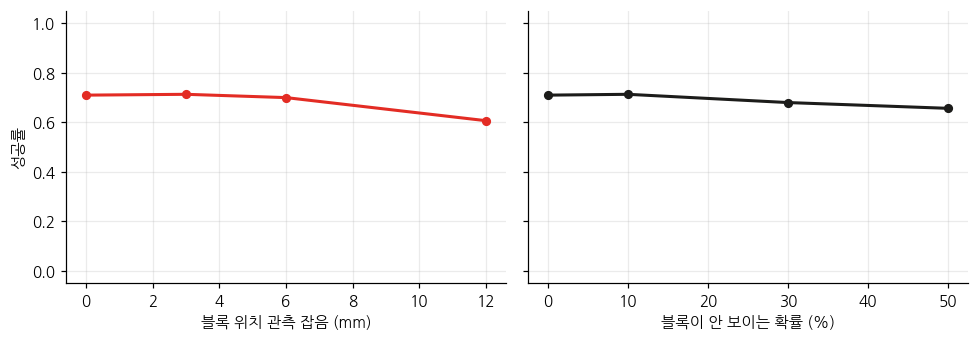

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.0, 3.2), sharey=True)
a1.plot([s * 1000 for s in NOISES], row, "o-", color=RED,
        lw=2, ms=5)
a1.set_xlabel("블록 위치 관측 잡음 (mm)")
a1.set_ylabel("성공률")
a2.plot([d * 100 for d in DROPS], row2, "o-", color=INK, lw=2, ms=5)
a2.set_xlabel("블록이 안 보이는 확률 (%)")
a1.set_ylim(-.05, 1.05)
plt.tight_layout()
plt.show()

## 정리

**이력으로 복원되는 값과 아닌 값이 있다.** 마찰은 몸으로 되돌아와 이력에 지문을 남기고, 블록의 위치는 그렇지 않다. 10장의 처방을 그대로 옮겼는데 같은 검사에서 결과가 갈렸다.

**그래서 조작은 외부 센서를 요구한다.** 로코모션이 고유수용만으로 갈 수 있었던 것은 알아야 할 것이 전부 몸을 통과하기 때문이다. 조작에서 물체는 몸 밖에 있다.

**외부 센서는 두 번째 갭을 데려온다.** 블록 위치에 몇 mm의 잡음만 섞여도 성공률이 크게 깎였다. 잡음은 매 스텝 다른 거짓말을 하기 때문에 가림보다 아프다.

**두 갭을 동시에 넘어야 한다는 것이 조작이 늦은 이유다.** 동역학 갭은 2부의 도구로 좁힐 수 있지만, 인식 갭은 그 도구가 잘 듣지 않는다.

여기까지가 3부다. 8장에서 병렬 환경으로 표본을 만들고, 9장에서 보상과 커리큘럼으로 학습을 세우고, 10장에서 특권 학습으로 실기에 올릴 정책을 뽑았다. 그리고 11장에서 그 파이프라인이 조작 앞에서 멈추는 자리를 봤다.

4부는 그 자리에서 시작한다. 인식 갭을 정면으로 다루는 길, 곧 **데이터를 만드는** 이야기다.